Data shape: (43300, 54)
Signal length: 43300
Peak frequency: 0.02 Hz
Estimated cycle duration: 40.96 s, 4096 frames
Suggested window_size: 4096, step: 2048


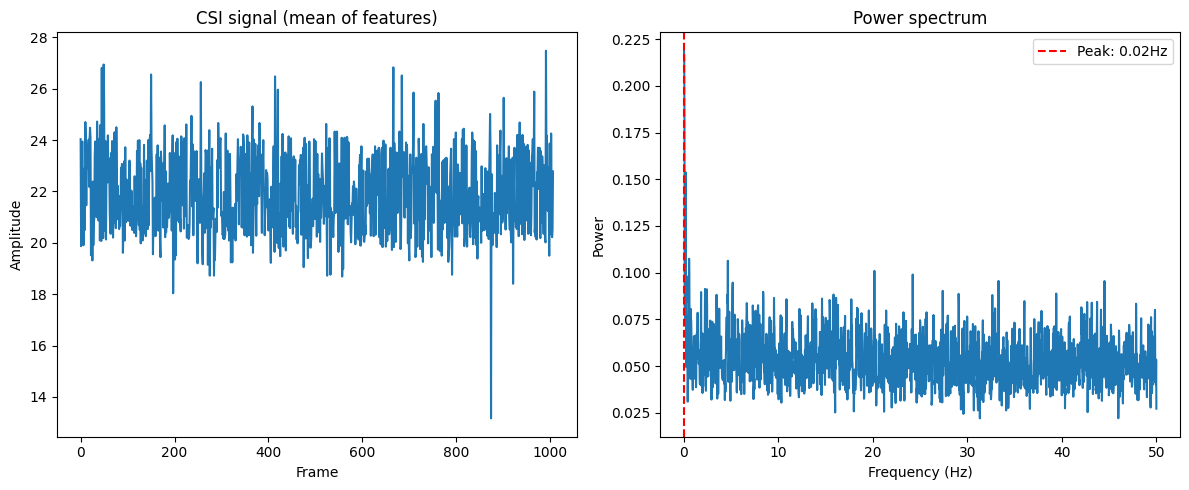

In [1]:
# estimate_cycle_fast.py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from src.preprocess import load_csi_csv
import traceback

# --- 1. Tham số ---
csv_path = "no_3.5_11.csv"  # file CSI
sample_rate = 100  # Hz

# --- 2. Load dữ liệu ---
try:
    data = load_csi_csv(csv_path)
    print("Data shape:", data.shape)
except Exception:
    traceback.print_exc()
    raise

# --- 3. Chọn 1 cột đại diện / trung bình ---
signal = data.mean(axis=1)
signal_len = len(signal)
print("Signal length:", signal_len)

# --- 4. Lấy subset để FFT nhanh nếu quá lớn ---
max_frames = 100_000  # chỉ dùng tối đa 100k frame
if signal_len > max_frames:
    signal_sub = signal[:max_frames]
    print(f"Using subset of {max_frames} frames for FFT")
else:
    signal_sub = signal

# --- 5. FFT / Welch ---
nperseg = min(4096, len(signal_sub))  # nperseg <= length
frequencies, power = welch(signal_sub, fs=sample_rate, nperseg=nperseg)

# --- 6. Tìm peak frequency ---
frequencies = frequencies[1:]
power = power[1:]
peak_idx = np.argmax(power)
peak_freq = frequencies[peak_idx]
print(f"Peak frequency: {peak_freq:.2f} Hz")

# --- 7. Tính chu kỳ ---
cycle_sec = 1.0 / peak_freq
cycle_frames = int(cycle_sec * sample_rate)
print(f"Estimated cycle duration: {cycle_sec:.2f} s, {cycle_frames} frames")

# --- 8. Window / step đề xuất ---
window_size = cycle_frames
step = max(1, window_size // 2)
print(f"Suggested window_size: {window_size}, step: {step}")

# --- 9. Vẽ nhanh ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(signal[::max(1, signal_len // 1000)])  # vẽ ~1000 điểm để nhanh
plt.title("CSI signal (mean of features)")
plt.xlabel("Frame")
plt.ylabel("Amplitude")

plt.subplot(1,2,2)
plt.plot(frequencies, power)
plt.title("Power spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.axvline(peak_freq, color='r', linestyle='--', label=f'Peak: {peak_freq:.2f}Hz')
plt.legend()
plt.tight_layout()
plt.show()

